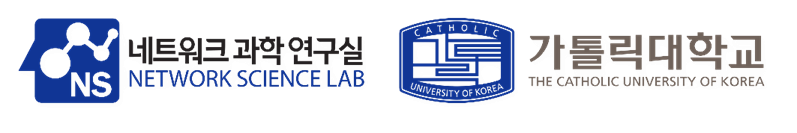

<a target="_blank" href="https://colab.research.google.com/github/NSLab-CUK/Graph-Mining-Spring-2026/blob/main/W10/Sample_Code_10.ipynb">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

# DeepWalk: Learning Node Representations

DeepWalk is an algorithm that learns a latent space representation (embedding) for nodes in a graph. It bridges graph theory and natural language processing by treating random walks on graphs like sentences in a text.

It consists of two main parts:
1. **Random Walk**: Generates sequences of nodes to capture local structures.
2. **SkipGram**: Uses these sequences to train a neural network that predicts a node's context (its neighbors in the walk).

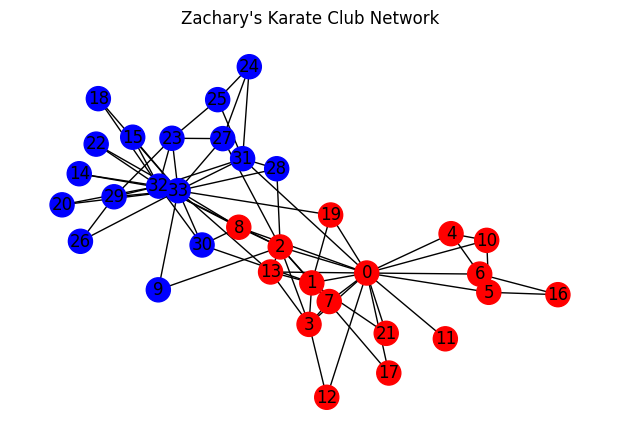

In [1]:
import networkx as nx
import random
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from tqdm import tqdm

# Import the Karate Club graph
karate_graph = nx.karate_club_graph()

# Get node colors based on their community ground truth
color_map = ["red" if karate_graph.nodes[n]["club"] == "Mr. Hi" else "blue" for n in karate_graph.nodes()]

# Draw the initial graph
plt.figure(figsize=(6, 4))
nx.draw(karate_graph, node_color=color_map, with_labels=True)
plt.title("Zachary's Karate Club Network")
plt.show()

In [2]:
def random_walk(graph, start_node, walk_length):
    """Generates a random walk of a specific length starting from a given node."""
    walk = [start_node]
    current_node = start_node
    
    for _ in range(walk_length - 1):
        # Sample uniformly from actual neighbors
        neighbors = list(graph.neighbors(current_node))
        if not neighbors:
            break
        current_node = random.choice(neighbors)
        walk.append(current_node)
        
    return walk

# Demonstrate random walks on the graph
sample_walk_length = 6

print("Sample Random Walks:")
for node in list(karate_graph.nodes())[:5]: # Show for first 5 nodes
    print(f"Node {node}: {random_walk(karate_graph, node, sample_walk_length)}")

Sample Random Walks:
Node 0: [0, 5, 6, 16, 5, 0]
Node 1: [1, 3, 12, 0, 13, 1]
Node 2: [2, 9, 33, 19, 1, 19]
Node 3: [3, 1, 3, 2, 28, 33]
Node 4: [4, 10, 5, 16, 5, 10]


## SkipGram Model

The SkipGram model takes a target node and tries to predict its context nodes (nodes that appear within a certain window size in the random walk). 
We define our embedding size `d` and initialize the embedding matrices. We aim to maximize the co-occurrence probability of context pairs.

In [3]:
class SkipGramModel(torch.nn.Module):
    def __init__(self, size_vertex, d):
        super(SkipGramModel, self).__init__()
        # Initializing embeddings for target nodes (phi) and context nodes (phi2)
        # Using d as the embedding dimension dimension.
        self.phi  = nn.Parameter(torch.rand((size_vertex, d), requires_grad=True))
        self.phi2 = nn.Parameter(torch.rand((d, size_vertex), requires_grad=True))

    def forward(self, one_hot):
        hidden = torch.matmul(one_hot, self.phi)
        # out predicts the probabilities of the context elements
        out = torch.matmul(hidden, self.phi2)
        return out

In [4]:
def skip_gram(model, walk, w, size_vertex, lr):
    """
    Trains the skip-gram model using a single random walk.
    w: context window size
    size_vertex: total number of nodes in graph
    lr: learning rate
    """
    for j in range(len(walk)):
        # Define context window for the current target node
        for k in range(max(0, j - w), min(j + w + 1, len(walk))):
            if j == k: 
                continue # Skip the target node itself
                
            # Generate one-hot vector for the target node
            one_hot = torch.zeros(size_vertex)
            one_hot[walk[j]] = 1

            # Forward pass
            out = model(one_hot)
            
            # Loss Function: NLL (Negative Log Likelihood) of a Softmax activation
            loss = torch.log(torch.sum(torch.exp(out))) - out[walk[k]]
            loss.backward()

            # Manual gradient descent step
            for param in model.parameters():
                param.data.sub_(lr * param.grad)
                param.grad.data.zero_()

In [5]:
# -----------------
# Hyperparameters
# -----------------
w = 3               # Context window size
d = 2               # Embedding size (2 dimensions to easily visualize)
y = 60              # Number of walks per vertex (epochs)
walk_length = 10    # Length of each random walk
lr = 0.05           # Learning rate
size_vertex = karate_graph.number_of_nodes() # Number of nodes (34)
nodes_list = list(karate_graph.nodes())

# Initialize model
model = SkipGramModel(size_vertex, d)

# -----------------
# Training Loop
# -----------------
print("Training started...")
for epoch in tqdm(range(y), desc="Epochs"):
    random.shuffle(nodes_list)
    
    for node in tqdm(nodes_list, desc=f"Epoch {epoch + 1}/{y}", leave=False):
        walk = random_walk(karate_graph, node, walk_length)
        skip_gram(model, walk, w, size_vertex, lr)

print("Training finished.")


Training started...


Epochs: 100%|██████████| 60/60 [00:18<00:00,  3.25it/s]

Training finished.


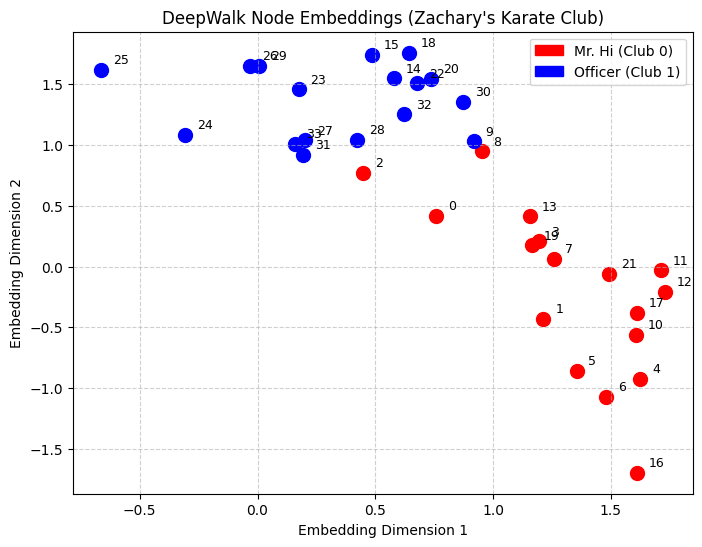

In [6]:
# Extract the learned embeddings from the model
embeddings = model.phi.detach().numpy()

# Visualize the embeddings in 2D space
plt.figure(figsize=(8, 6))

# Plot each node, colored by its true community
for i in range(size_vertex):
    plt.scatter(embeddings[i, 0], embeddings[i, 1], color=color_map[i], s=100)
    plt.annotate(str(i), (embeddings[i, 0] + 0.05, embeddings[i, 1] + 0.05), fontsize=9)

plt.title("DeepWalk Node Embeddings (Zachary's Karate Club)")
plt.xlabel("Embedding Dimension 1")
plt.ylabel("Embedding Dimension 2")
plt.grid(True, linestyle='--', alpha=0.6)

import matplotlib.patches as mpatches
red_patch = mpatches.Patch(color='red', label='Mr. Hi (Club 0)')
blue_patch = mpatches.Patch(color='blue', label='Officer (Club 1)')
plt.legend(handles=[red_patch, blue_patch])

plt.show()